In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 50)

In [6]:
trans = pd.read_csv('train_transaction.csv')
iden  = pd.read_csv('train_identity.csv')

df = trans.merge(iden, on='TransactionID', how='left')
print(df.head())

print("Shape after merge:", df.shape)
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean()*100:.2f}%")

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5   card6  addr1  addr2  dist1  dist2  \
0    NaN  150.0    discover  142.0  credit  315.0   87.0   19.0    NaN   
1  404.0  150.0  mastercard  102.0  credit  325.0   87.0    NaN    NaN   
2  490.0  150.0        visa  166.0   debit  330.0   87.0  287.0    NaN   
3  567.0  150.0  mastercard  117.0   debit  476.0   87.0    NaN    NaN   
4  514.0  150.0  mastercard  102.0  credit  420.0   87.0    NaN    NaN   

  P_emaildomain R_emaildomain   C1   C2   C3   C4   C5   C6   C7   C8  ...  \
0           Na

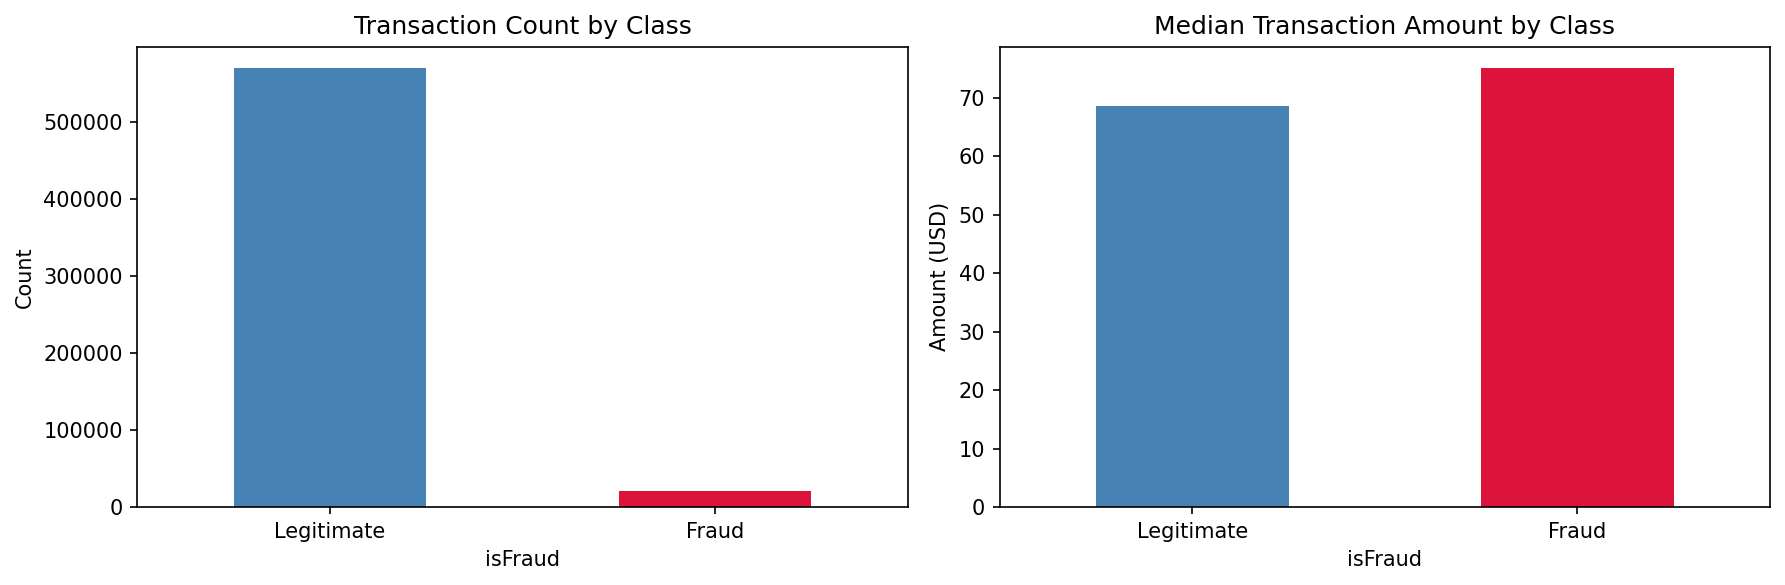

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# Transaction amount by class
df.groupby('isFraud')['TransactionAmt'].median().plot(kind='bar', ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('Median Transaction Amount by Class')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[1].set_ylabel('Amount (USD)')

plt.tight_layout()
plt.show()

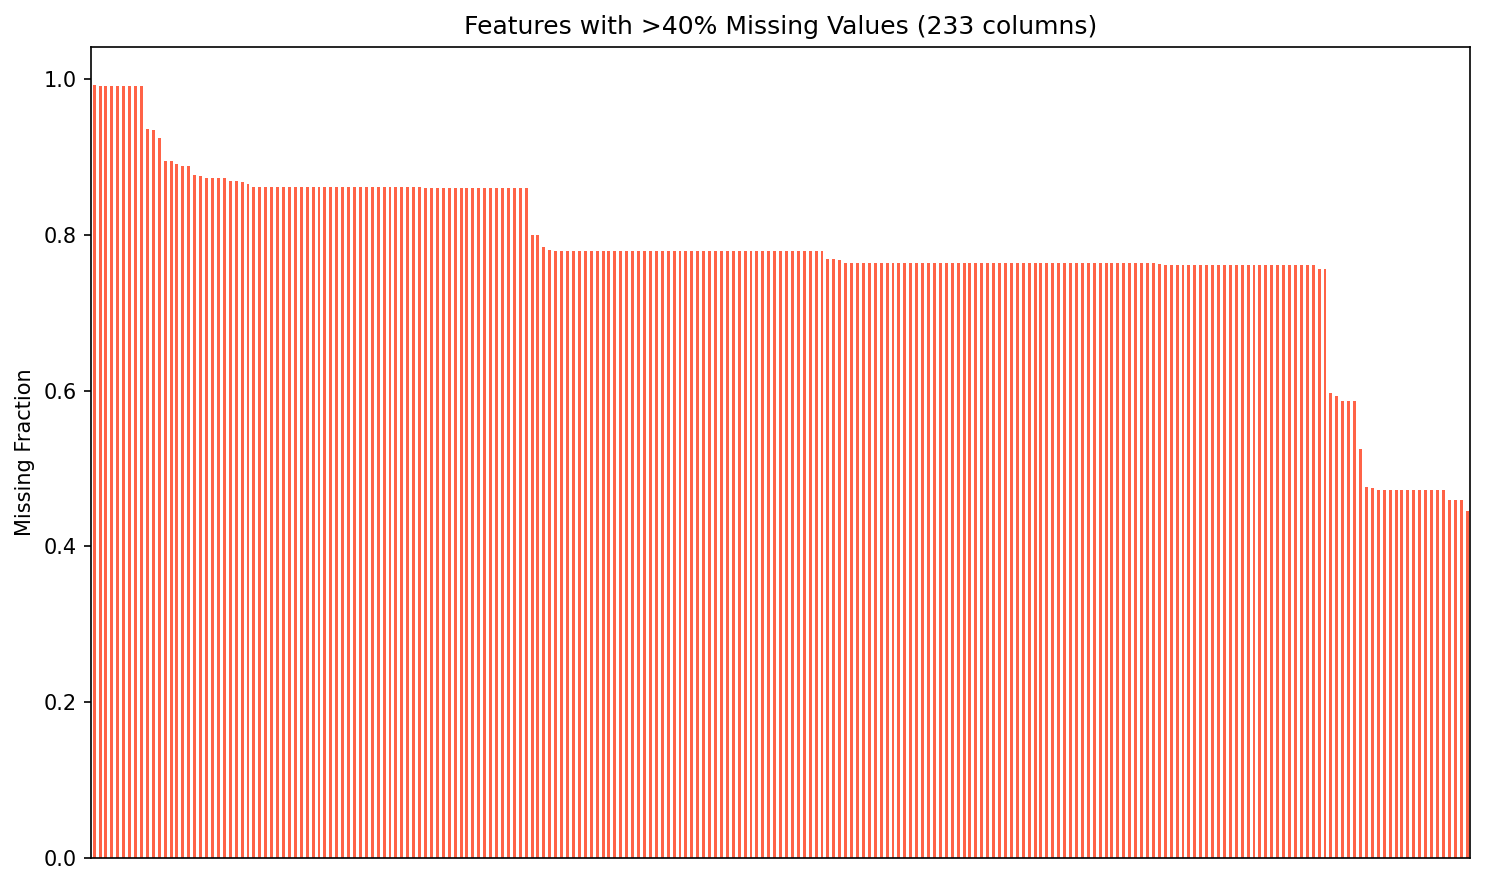

Total columns: 456
Columns with >40% missing: 233
Columns with >80% missing: 74


In [50]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_high = missing[missing > 0.4]

plt.figure(figsize=(10, 6))
missing_high.plot(kind='bar', color='tomato')
plt.title(f'Features with >40% Missing Values ({len(missing_high)} columns)')
plt.ylabel('Missing Fraction')
plt.xticks([])   # too many to label
plt.tight_layout()
plt.show()

print(f"Total columns: {df.shape[1]}")
print(f"Columns with >40% missing: {len(missing_high)}")
print(f"Columns with >80% missing: {(missing > 0.8).sum()}")

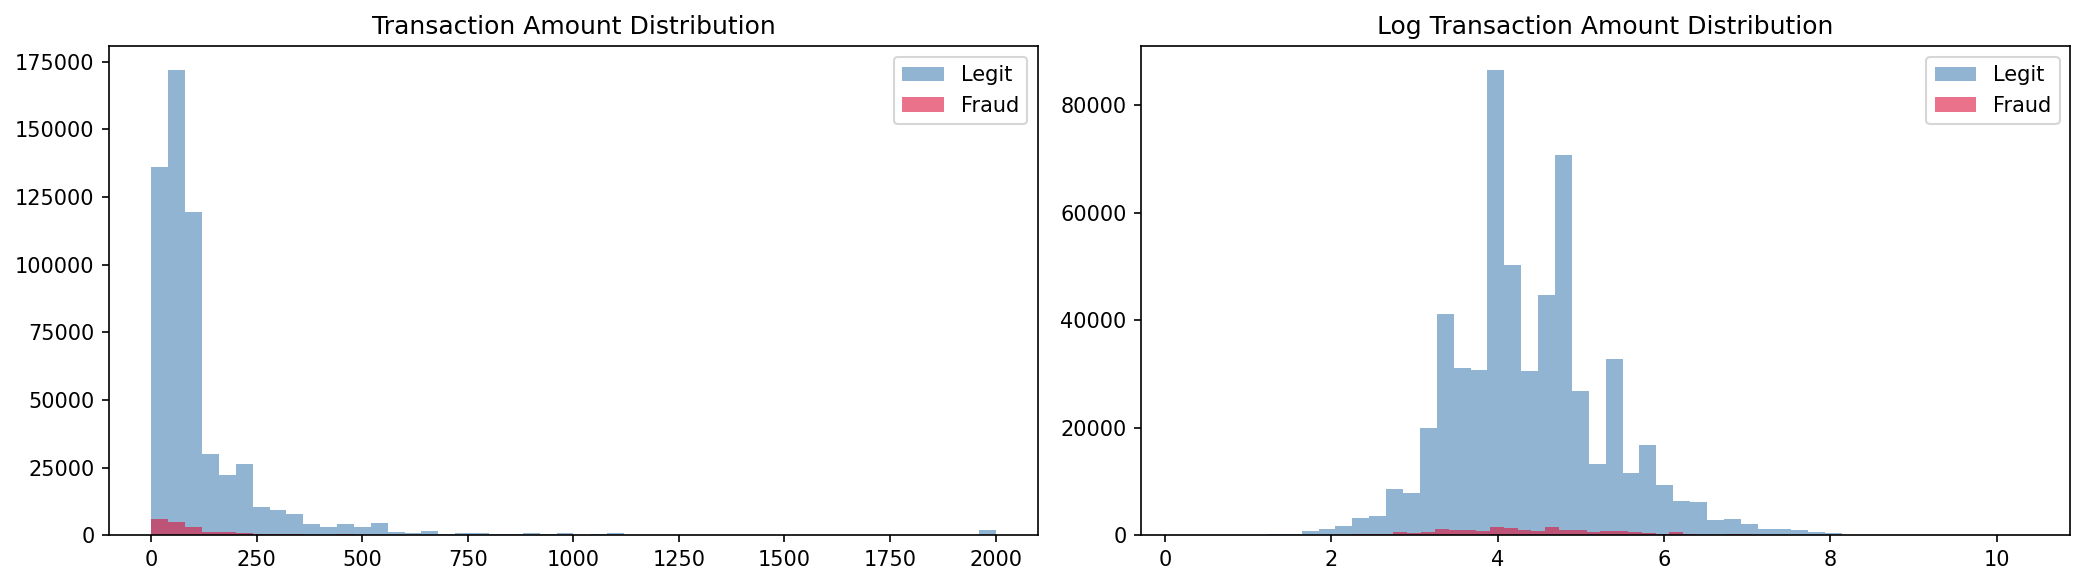

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw
axes[0].hist(df[df['isFraud']==0]['TransactionAmt'].clip(upper=2000),
             bins=50, alpha=0.6, label='Legit', color='steelblue')
axes[0].hist(df[df['isFraud']==1]['TransactionAmt'].clip(upper=2000),
             bins=50, alpha=0.6, label='Fraud', color='crimson')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(df[df['isFraud']==0]['TransactionAmt']),
             bins=50, alpha=0.6, label='Legit', color='steelblue')
axes[1].hist(np.log1p(df[df['isFraud']==1]['TransactionAmt']),
             bins=50, alpha=0.6, label='Fraud', color='crimson')
axes[1].set_title('Log Transaction Amount Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

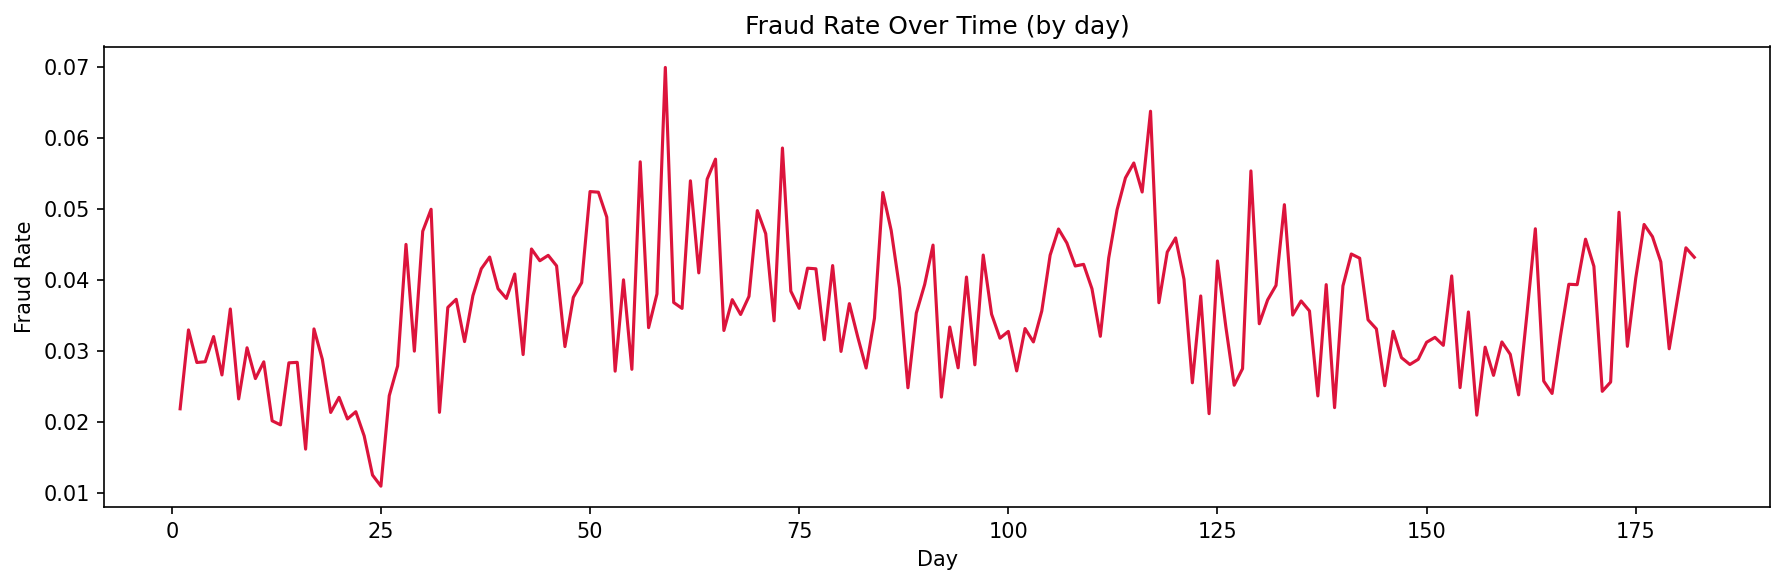

In [49]:
# TransactionDT is seconds elapsed — convert to days
df['day'] = df['TransactionDT'] // (24 * 60 * 60)

daily_fraud = df.groupby('day')['isFraud'].mean()

plt.figure(figsize=(12, 4))
daily_fraud.plot(color='crimson')
plt.title('Fraud Rate Over Time (by day)')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [10]:
# Drop columns with >80% missing
thresh = 0.8
cols_to_keep = df.columns[df.isnull().mean() < thresh]
df_clean = df[cols_to_keep].copy()

print(f"Columns after dropping high-missing: {df_clean.shape[1]}")

# Separate target
y = df_clean['isFraud']
X = df_clean.drop(columns=['isFraud', 'TransactionID'])

# Encode all categorical columns
cat_cols = X.select_dtypes(include='object').columns
print(f"Categorical columns to encode: {list(cat_cols)}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"\nFinal feature matrix: {X_imputed.shape}")
print(f"Any nulls remaining: {X_imputed.isnull().any().any()}")

Columns after dropping high-missing: 361
Categorical columns to encode: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Final feature matrix: (590540, 359)
Any nulls remaining: False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve fraud ratio in both splits
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.2f}%")

Train size: 472,432
Test size:  118,108
Train fraud rate: 3.50%
Test fraud rate:  3.50%


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles class imbalance
    max_depth=12,
    n_jobs=-1,                # use all CPU cores
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   16.5s


Training complete.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   57.7s finished


In [13]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Legit       0.99      0.90      0.95    113975
       Fraud       0.22      0.73      0.34      4133

    accuracy                           0.90    118108
   macro avg       0.60      0.82      0.64    118108
weighted avg       0.96      0.90      0.92    118108

AUC-ROC Score: 0.8986


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.5s finished


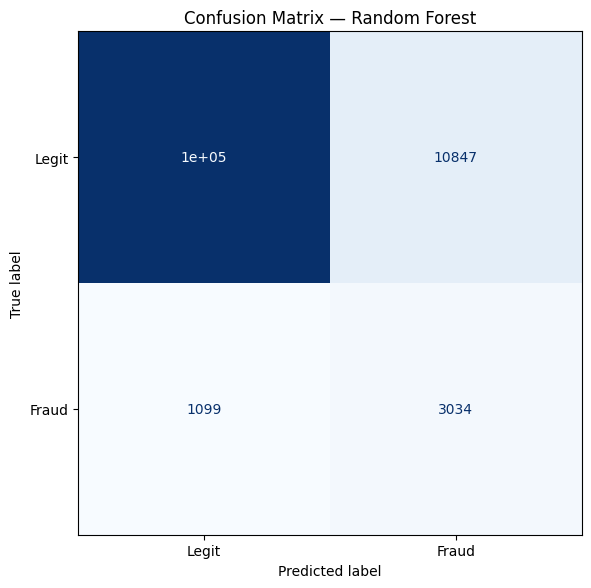


True Negatives  (Legit correctly identified): 103,128
False Positives (Legit flagged as Fraud):     10,847
False Negatives (Fraud missed):               1,099
True Positives  (Fraud correctly caught):     3,034


In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Legit correctly identified): {tn:,}")
print(f"False Positives (Legit flagged as Fraud):     {fp:,}")
print(f"False Negatives (Fraud missed):               {fn:,}")
print(f"True Positives  (Fraud correctly caught):     {tp:,}")

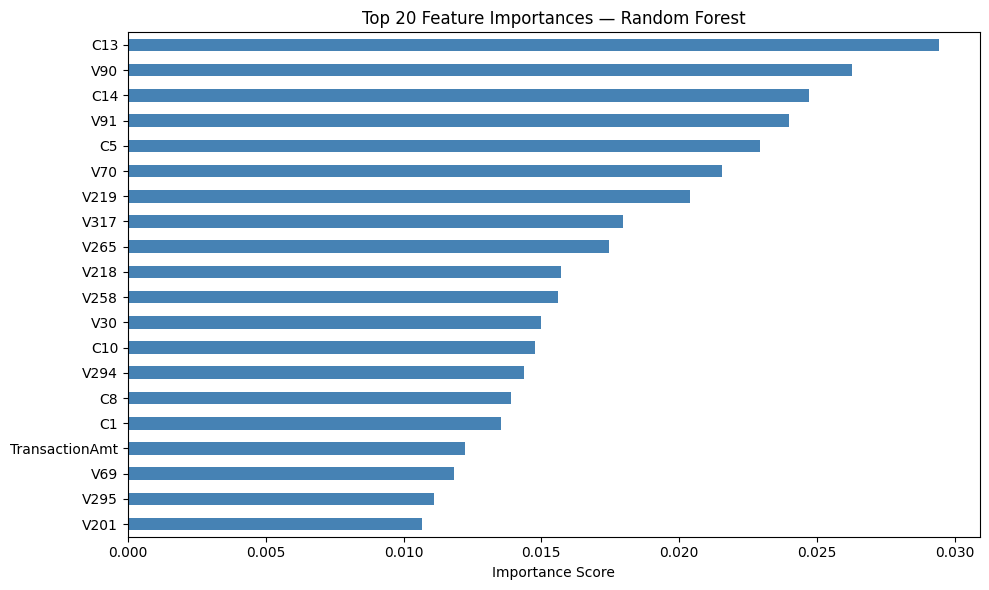

In [15]:
importances = pd.Series(rf.feature_importances_, index=X_imputed.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Convert TransactionDT to interpretable time features
df['hour']    = (df['TransactionDT'] // 3600) % 24
df['day']     =  df['TransactionDT'] // (24 * 3600)
df['weekday'] =  df['day'] % 7

# Cyclic encoding so hour 23 and hour 0 are close together
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

print("Time features created")
print(df[['hour', 'weekday', 'hour_sin', 'hour_cos']].head())

Time features created
   hour  weekday  hour_sin  hour_cos
0     0        1       0.0       1.0
1     0        1       0.0       1.0
2     0        1       0.0       1.0
3     0        1       0.0       1.0
4     0        1       0.0       1.0


In [17]:
# Per-card transaction count and amount stats
# This captures the "velocity" concept from your paper

card_stats = df.groupby('card1').agg(
    card_txn_count    = ('TransactionAmt', 'count'),
    card_amt_mean     = ('TransactionAmt', 'mean'),
    card_amt_std      = ('TransactionAmt', 'std'),
    card_amt_max      = ('TransactionAmt', 'max'),
).reset_index()

df = df.merge(card_stats, on='card1', how='left')

# How much does this transaction deviate from this card's average?
df['amt_deviation'] = (df['TransactionAmt'] - df['card_amt_mean']) / (df['card_amt_std'] + 1e-8)

print("Behavioral features created")
print(df[['card1', 'TransactionAmt', 'card_amt_mean', 'amt_deviation']].head(10))

Behavioral features created
   card1  TransactionAmt  card_amt_mean  amt_deviation
0  13926            68.5     351.931163      -0.763675
1   2755            29.0     234.292753      -0.445943
2   4663            59.0      97.015542      -0.379666
3  18132            50.0     123.416340      -0.380953
4   4497            50.0      96.972222      -0.829466
5   5937            49.0     134.071429      -0.852783
6  12308           159.0     101.880097       0.323214
7  12695           422.5     141.144645       1.306911
8   2803            15.0     142.683409      -0.487373
9  17399           117.0     122.020491      -0.025208


In [18]:
# Is this a new device for this card?
card_device = df.groupby(['card1', 'DeviceInfo']).size().reset_index(name='card_device_count')
df = df.merge(card_device, on=['card1', 'DeviceInfo'], how='left')

# Frequency encode email domains — rare domains are more suspicious
p_email_freq = df['P_emaildomain'].value_counts() / len(df)
r_email_freq = df['R_emaildomain'].value_counts() / len(df)

df['P_email_freq'] = df['P_emaildomain'].map(p_email_freq).fillna(0)
df['R_email_freq'] = df['R_emaildomain'].map(r_email_freq).fillna(0)

# Flag mismatched email domains
df['email_mismatch'] = (df['P_emaildomain'] != df['R_emaildomain']).astype(int)

print("Device and email features created")
print(df[['P_emaildomain', 'P_email_freq', 'R_emaildomain', 'R_email_freq', 'email_mismatch']].head(10))

Device and email features created
   P_emaildomain  P_email_freq R_emaildomain  R_email_freq  email_mismatch
0            NaN      0.000000           NaN           0.0               1
1      gmail.com      0.386688           NaN           0.0               1
2    outlook.com      0.008629           NaN           0.0               1
3      yahoo.com      0.170918           NaN           0.0               1
4      gmail.com      0.386688           NaN           0.0               1
5      gmail.com      0.386688           NaN           0.0               1
6      yahoo.com      0.170918           NaN           0.0               1
7       mail.com      0.000947           NaN           0.0               1
8  anonymous.com      0.062651           NaN           0.0               1
9      yahoo.com      0.170918           NaN           0.0               1


In [19]:
# Drop columns with >80% missing
thresh = 0.8
cols_to_keep = df.columns[df.isnull().mean() < thresh]
df_model = df[cols_to_keep].copy()

# Drop columns we don't need for modeling
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT',
             'hour', 'weekday',           # already encoded cyclically
             'P_emaildomain', 'R_emaildomain',  # already frequency encoded
             'DeviceInfo'                 # already captured in card_device_count
             ]
drop_cols = [c for c in drop_cols if c in df_model.columns]

y = df_model['isFraud']
X = df_model.drop(columns=drop_cols)

# Encode remaining categoricals
cat_cols = X.select_dtypes(include='object').columns
print(f"Encoding {len(cat_cols)} categorical columns: {list(cat_cols)}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# Impute
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"\nFinal feature matrix shape: {X_imputed.shape}")
print(f"Any nulls: {X_imputed.isnull().any().any()}")

Encoding 23 categorical columns: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']

Final feature matrix shape: (590540, 368)
Any nulls: False


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.2f}%")

Train: 472,432 rows
Test:  118,108 rows
Train fraud rate: 3.50%
Test fraud rate:  3.50%


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   15.6s


Training complete.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   58.1s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.4s finished


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

       Legit       0.99      0.91      0.95    113975
       Fraud       0.23      0.74      0.35      4133

    accuracy                           0.91    118108
   macro avg       0.61      0.82      0.65    118108
weighted avg       0.96      0.91      0.93    118108

AUC-ROC: 0.9033


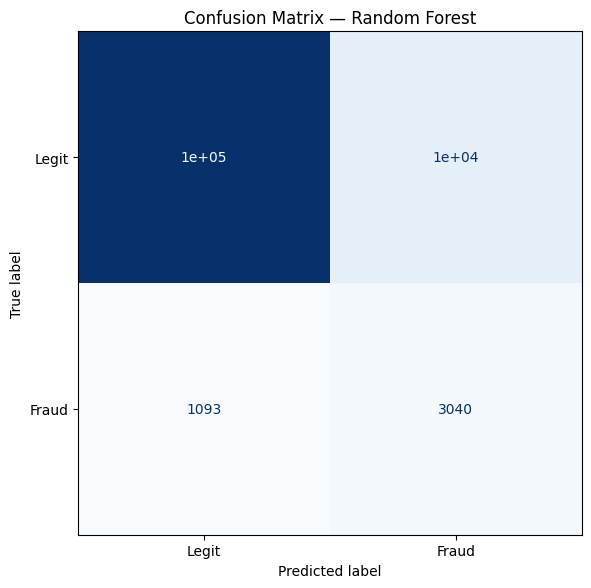

In [22]:
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

In [23]:
# Train ONLY on legitimate transactions — it learns what "normal" looks like
X_train_legit = X_train[y_train == 0]

iso = IsolationForest(
    n_estimators=100,
    contamination=0.035,   # approximate fraud rate in dataset
    n_jobs=-1,
    random_state=42,
    verbose=1
)

iso.fit(X_train_legit)
print("Isolation Forest training complete.")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.6s remaining:    4.7s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


Isolation Forest training complete.


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished


In [24]:
# decision_function: lower score = more anomalous
iso_scores_train = iso.decision_function(X_train)
iso_scores_test  = iso.decision_function(X_test)

# Normalize to [0, 1] and flip so higher = more anomalous
def normalize_scores(scores):
    s = -scores   # flip sign
    return (s - s.min()) / (s.max() - s.min())

iso_norm_train = normalize_scores(iso_scores_train)
iso_norm_test  = normalize_scores(iso_scores_test)

# Quick check — are anomaly scores higher for fraud?
fraud_mask_test = y_test.values == 1
print(f"Mean anomaly score — Legit: {iso_norm_test[~fraud_mask_test].mean():.3f}")
print(f"Mean anomaly score — Fraud: {iso_norm_test[fraud_mask_test].mean():.3f}")
# Fraud should be noticeably higher

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


Mean anomaly score — Legit: 0.106
Mean anomaly score — Fraud: 0.280


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished


In [25]:
# Add anomaly score as extra feature and combine with RF probability
# Simple weighted fusion for now

rf_weight  = 0.7
iso_weight = 0.3

final_scores_test = (rf_weight * y_prob_rf) + (iso_weight * iso_norm_test)

# Evaluate fusion at threshold 0.5
y_pred_fused = (final_scores_test >= 0.5).astype(int)

print("=" * 50)
print("FUSED MODEL RESULTS (RF + Isolation Forest)")
print("=" * 50)
print(classification_report(y_test, y_pred_fused, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, final_scores_test):.4f}")

FUSED MODEL RESULTS (RF + Isolation Forest)
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98    113975
       Fraud       0.41      0.61      0.49      4133

    accuracy                           0.96    118108
   macro avg       0.70      0.79      0.73    118108
weighted avg       0.97      0.96      0.96    118108

AUC-ROC: 0.8963


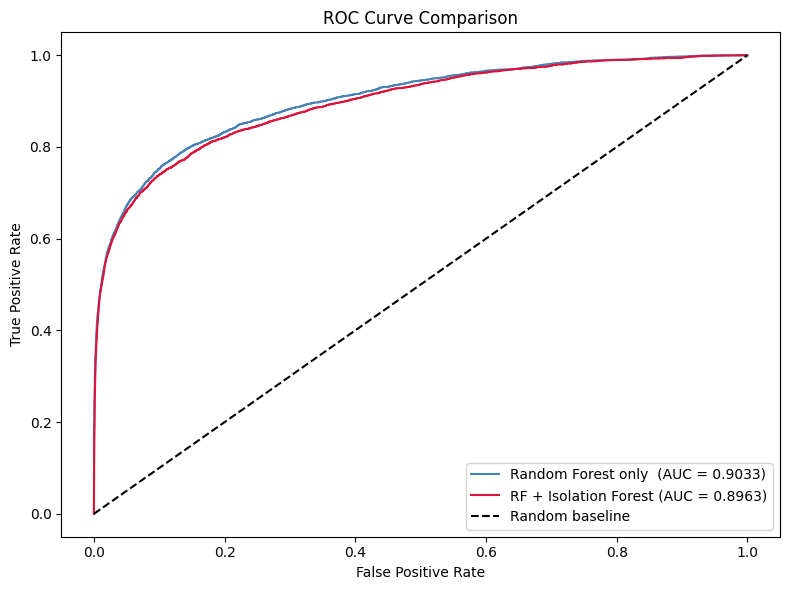

In [26]:
from sklearn.metrics import roc_curve

fpr_rf,    tpr_rf,    _ = roc_curve(y_test, y_prob_rf)
fpr_fused, tpr_fused, _ = roc_curve(y_test, final_scores_test)

auc_rf    = roc_auc_score(y_test, y_prob_rf)
auc_fused = roc_auc_score(y_test, final_scores_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,    tpr_rf,    label=f'Random Forest only  (AUC = {auc_rf:.4f})', color='steelblue')
plt.plot(fpr_fused, tpr_fused, label=f'RF + Isolation Forest (AUC = {auc_fused:.4f})', color='crimson')
plt.plot([0,1],[0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Try different weights and see which AUC is best
results = []

for rf_w in np.arange(0.5, 1.0, 0.05):
    iso_w = 1 - rf_w
    scores = (rf_w * y_prob_rf) + (iso_w * iso_norm_test)
    auc = roc_auc_score(y_test, scores)
    results.append((round(rf_w, 2), round(iso_w, 2), round(auc, 4)))

results_df = pd.DataFrame(results, columns=['RF weight', 'ISO weight', 'AUC'])
print(results_df.to_string(index=False))

best = results_df.loc[results_df['AUC'].idxmax()]
print(f"\nBest combination: RF={best['RF weight']}, ISO={best['ISO weight']}, AUC={best['AUC']}")

 RF weight  ISO weight    AUC
      0.50        0.50 0.8837
      0.55        0.45 0.8878
      0.60        0.40 0.8912
      0.65        0.35 0.8940
      0.70        0.30 0.8963
      0.75        0.25 0.8981
      0.80        0.20 0.8998
      0.85        0.15 0.9010
      0.90        0.10 0.9020
      0.95        0.05 0.9027

Best combination: RF=0.95, ISO=0.05, AUC=0.9027


In [28]:
import xgboost as xgb

# Build a small meta-feature matrix
# RF probability + ISO anomaly score -> XGBoost decides how to combine them
X_meta_train = np.column_stack([
    rf.predict_proba(X_train)[:, 1],   # RF fraud probability
    iso_norm_train,                      # ISO anomaly score
])

X_meta_test = np.column_stack([
    y_prob_rf,          # already computed
    iso_norm_test,      # already computed
])

meta_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),  # handles imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

meta_clf.fit(X_meta_train, y_train)

y_prob_meta = meta_clf.predict_proba(X_meta_test)[:, 1]
y_pred_meta = meta_clf.predict(X_meta_test)

print("=" * 50)
print("META-CLASSIFIER RESULTS (Stage 3 — XGBoost)")
print("=" * 50)
print(classification_report(y_test, y_pred_meta, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_meta):.4f}")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.7s finished


META-CLASSIFIER RESULTS (Stage 3 — XGBoost)
              precision    recall  f1-score   support

       Legit       0.99      0.89      0.94    113975
       Fraud       0.20      0.76      0.32      4133

    accuracy                           0.88    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.88      0.92    118108

AUC-ROC: 0.9025


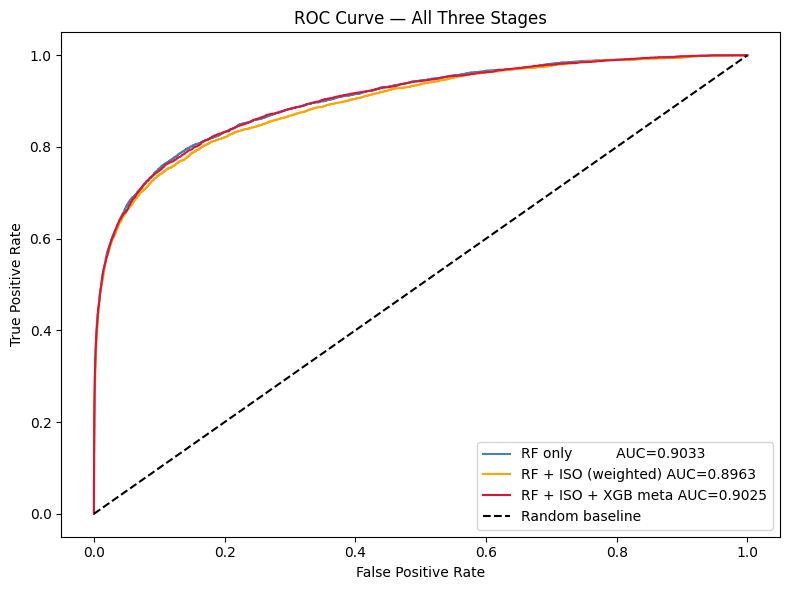

In [29]:
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_fused,tpr_fused,_ = roc_curve(y_test, final_scores_test)
fpr_meta, tpr_meta, _ = roc_curve(y_test, y_prob_meta)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf,    tpr_rf,    label=f'RF only          AUC={roc_auc_score(y_test, y_prob_rf):.4f}',    color='steelblue')
plt.plot(fpr_fused, tpr_fused, label=f'RF + ISO (weighted) AUC={roc_auc_score(y_test, final_scores_test):.4f}', color='orange')
plt.plot(fpr_meta,  tpr_meta,  label=f'RF + ISO + XGB meta AUC={roc_auc_score(y_test, y_prob_meta):.4f}',  color='crimson')
plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Three Stages')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Cell 27 — Retrain ISO on behavioral features only
behavioral_cols = [
    'TransactionAmt',
    'card_txn_count',
    'card_amt_mean',
    'card_amt_std',
    'amt_deviation',
    'card_device_count',
    'P_email_freq',
    'R_email_freq',
    'email_mismatch',
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'D1', 'D2', 'D4',     # time deltas
    'C1', 'C2', 'C5',     # count features
]

# Keep only columns that actually exist in X_train
behavioral_cols = [c for c in behavioral_cols if c in X_train.columns]
print(f"Using {len(behavioral_cols)} behavioral features: {behavioral_cols}")

X_train_behavioral = X_train[behavioral_cols]
X_test_behavioral  = X_test[behavioral_cols]

# Train ISO on only legit transactions, behavioral features only
X_train_legit_b = X_train_behavioral[y_train == 0]

iso_b = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    n_jobs=-1,
    random_state=42
)

iso_b.fit(X_train_legit_b)

# Get new anomaly scores
iso_scores_train_b = iso_b.decision_function(X_train_behavioral)
iso_scores_test_b  = iso_b.decision_function(X_test_behavioral)

iso_norm_train_b = normalize_scores(iso_scores_train_b)
iso_norm_test_b  = normalize_scores(iso_scores_test_b)

# Quick sanity check
fraud_mask = y_test.values == 1
print(f"\nBehavioral ISO scores:")
print(f"Mean — Legit: {iso_norm_test_b[~fraud_mask].mean():.3f}")
print(f"Mean — Fraud: {iso_norm_test_b[fraud_mask].mean():.3f}")

Using 19 behavioral features: ['TransactionAmt', 'card_txn_count', 'card_amt_mean', 'card_amt_std', 'amt_deviation', 'card_device_count', 'P_email_freq', 'R_email_freq', 'email_mismatch', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'D1', 'D2', 'D4', 'C1', 'C2', 'C5']

Behavioral ISO scores:
Mean — Legit: 0.236
Mean — Fraud: 0.323


In [31]:
# Cell 28 — Retrain XGBoost meta with better ISO scores
X_meta_train_b = np.column_stack([
    rf.predict_proba(X_train)[:, 1],
    iso_norm_train_b,
])

X_meta_test_b = np.column_stack([
    y_prob_rf,
    iso_norm_test_b,
])

meta_clf_b = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

meta_clf_b.fit(X_meta_train_b, y_train)

y_prob_meta_b = meta_clf_b.predict_proba(X_meta_test_b)[:, 1]

print("=" * 50)
print("IMPROVED META-CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, meta_clf_b.predict(X_meta_test_b), target_names=['Legit','Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_meta_b):.4f}")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.9s finished


IMPROVED META-CLASSIFIER
              precision    recall  f1-score   support

       Legit       0.99      0.90      0.94    113975
       Fraud       0.21      0.76      0.33      4133

    accuracy                           0.89    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.89      0.92    118108

AUC-ROC: 0.9040


In [32]:
# Create a user identifier
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)

# Per-user aggregates
uid_stats = df.groupby('uid').agg(
    uid_txn_count  = ('TransactionAmt', 'count'),
    uid_amt_mean   = ('TransactionAmt', 'mean'),
    uid_amt_std    = ('TransactionAmt', 'std'),
    uid_fraud_mean = ('isFraud', 'mean'),   # historical fraud rate for this user
).reset_index()

df = df.merge(uid_stats, on='uid', how='left')

# How much does this transaction deviate from THIS USER's average
df['uid_amt_deviation'] = (
    (df['TransactionAmt'] - df['uid_amt_mean']) / (df['uid_amt_std'] + 1e-8)
)

print(df[['uid', 'TransactionAmt', 'uid_amt_mean', 'uid_amt_deviation', 'uid_fraud_mean']].head(10))

           uid  TransactionAmt  uid_amt_mean  uid_amt_deviation  \
0  13926_315.0            68.5    142.000000          -0.481481   
1   2755_325.0            29.0    275.521639          -0.404297   
2   4663_330.0            59.0     52.433529           0.297718   
3  18132_476.0            50.0    124.769533          -0.300869   
4   4497_420.0            50.0     50.000000                NaN   
5   5937_272.0            49.0    116.300000          -0.578852   
6  12308_126.0           159.0    159.000000                NaN   
7  12695_325.0           422.5    142.740376           1.285430   
8   2803_337.0            15.0    133.516195          -0.475217   
9  17399_204.0           117.0    121.898649          -0.024113   

   uid_fraud_mean  
0        0.000000  
1        0.000000  
2        0.000000  
3        0.031128  
4        0.000000  
5        0.000000  
6        0.000000  
7        0.031174  
8        0.009434  
9        0.012182  


In [33]:
# Rebuild feature matrix from scratch with uid features included
thresh = 0.8
cols_to_keep = df.columns[df.isnull().mean() < thresh]
df_model2 = df[cols_to_keep].copy()

drop_cols2 = [
    'TransactionID', 'isFraud', 'TransactionDT',
    'hour', 'weekday',
    'P_emaildomain', 'R_emaildomain',
    'DeviceInfo', 'uid',
    'day'
]
drop_cols2 = [c for c in drop_cols2 if c in df_model2.columns]

y2 = df_model2['isFraud']
X2 = df_model2.drop(columns=drop_cols2)

# Encode categoricals
cat_cols2 = X2.select_dtypes(include='object').columns
for col in cat_cols2:
    X2[col] = X2[col].astype(str)
    X2[col] = le.fit_transform(X2[col])

# Impute
X2_imputed = pd.DataFrame(
    imputer.fit_transform(X2), columns=X2.columns
)

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_imputed, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print(f"New feature matrix: {X2_imputed.shape}")

New feature matrix: (590540, 372)


In [34]:
rf2 = RandomForestClassifier(
    n_estimators=200,       # more trees
    class_weight='balanced',
    max_depth=15,           # slightly deeper
    min_samples_leaf=10,    # prevents overfitting
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf2.fit(X2_train, y2_train)
print("Done.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   22.6s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.2min


Done.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.6min finished


In [35]:
y2_prob = rf2.predict_proba(X2_test)[:, 1]
y2_pred = rf2.predict(X2_test)

print("=" * 50)
print("RF v2 — WITH UID FEATURES")
print("=" * 50)
print(classification_report(y2_test, y2_pred, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y2_test, y2_prob):.4f}")

# Compare
print(f"\nRF v1 AUC: 0.9033")
print(f"RF v2 AUC: {roc_auc_score(y2_test, y2_prob):.4f}")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    1.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    1.2s finished


RF v2 — WITH UID FEATURES
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.97    113975
       Fraud       0.40      0.81      0.54      4133

    accuracy                           0.95    118108
   macro avg       0.70      0.89      0.76    118108
weighted avg       0.97      0.95      0.96    118108

AUC-ROC: 0.9606

RF v1 AUC: 0.9033
RF v2 AUC: 0.9606


In [36]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,              # use 80% of rows per tree
    colsample_bytree=0.8,       # use 80% of features per tree
    scale_pos_weight=(y2_train==0).sum() / (y2_train==1).sum(),
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,   # stop if no improvement for 20 rounds
    verbosity=1,
    n_jobs=-1,
)

xgb_model.fit(
    X2_train, y2_train,
    eval_set=[(X2_test, y2_test)],
    verbose=50      # print every 50 rounds
)

print("XGBoost training complete.")

[0]	validation_0-auc:0.94032
[50]	validation_0-auc:0.96062
[100]	validation_0-auc:0.96486
[150]	validation_0-auc:0.96784
[200]	validation_0-auc:0.97049
[250]	validation_0-auc:0.97263
[300]	validation_0-auc:0.97440
[350]	validation_0-auc:0.97567
[400]	validation_0-auc:0.97669
[450]	validation_0-auc:0.97777
[499]	validation_0-auc:0.97854
XGBoost training complete.


In [37]:
y_prob_xgb = xgb_model.predict_proba(X2_test)[:, 1]
y_pred_xgb = xgb_model.predict(X2_test)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y2_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y2_test, y_prob_xgb):.4f}")

print(f"\nRF v1  AUC: 0.9033")
print(f"RF v2  AUC: 0.9606")
print(f"XGB    AUC: {roc_auc_score(y2_test, y_prob_xgb):.4f}")

XGBOOST RESULTS
              precision    recall  f1-score   support

       Legit       1.00      0.94      0.97    113975
       Fraud       0.36      0.89      0.52      4133

    accuracy                           0.94    118108
   macro avg       0.68      0.92      0.74    118108
weighted avg       0.97      0.94      0.95    118108

AUC-ROC: 0.9785

RF v1  AUC: 0.9033
RF v2  AUC: 0.9606
XGB    AUC: 0.9785


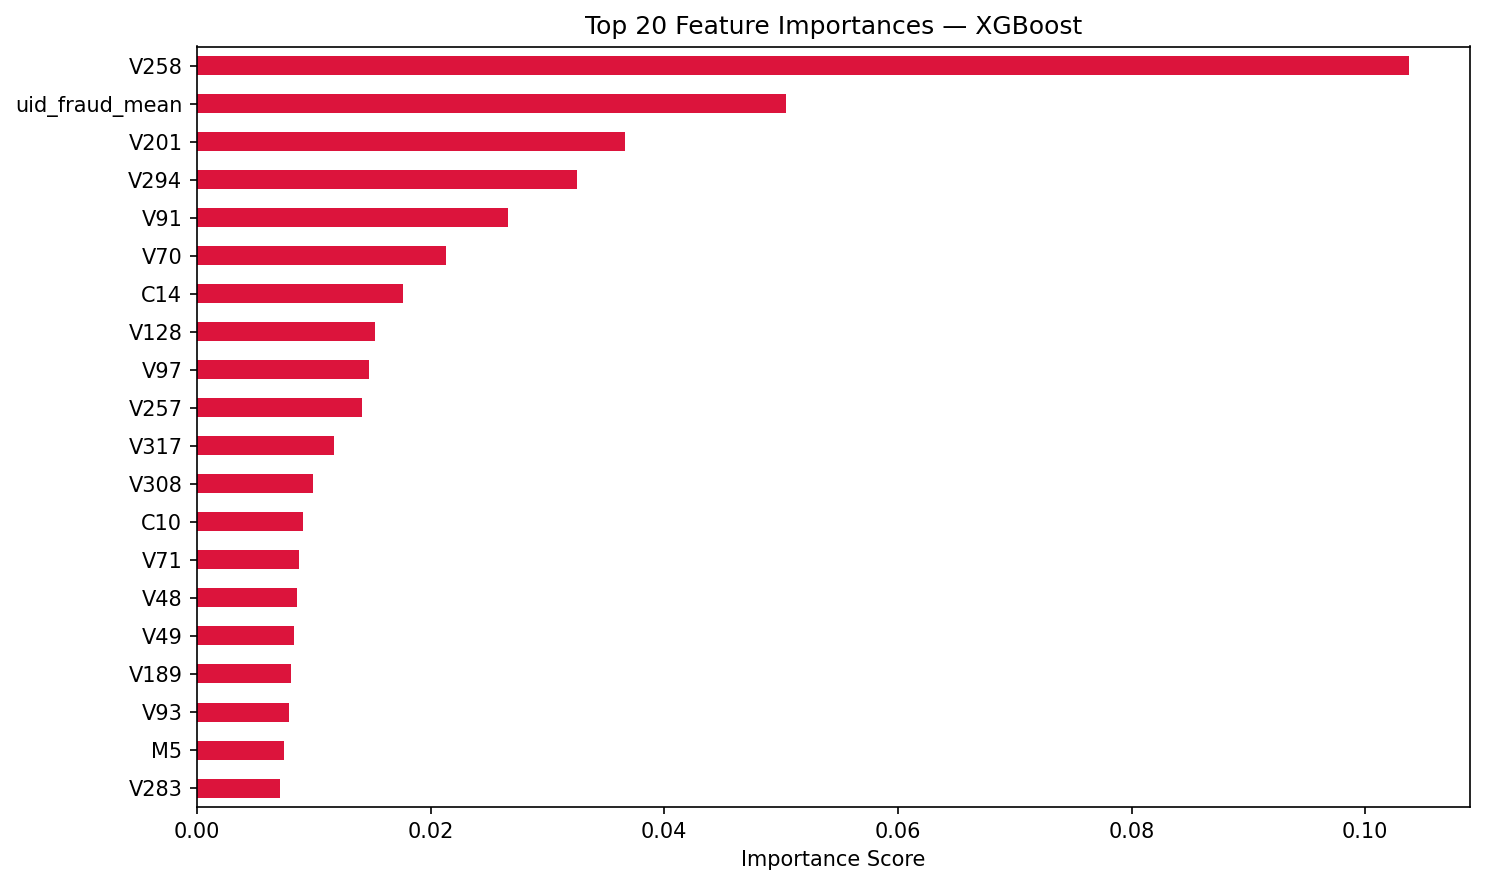


Top 10 features:
V258              0.103786
uid_fraud_mean    0.050434
V201              0.036619
V294              0.032529
V91               0.026602
V70               0.021361
C14               0.017623
V128              0.015266
V97               0.014769
V257              0.014134
dtype: float32


In [51]:
importances_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X2_imputed.columns
).sort_values(ascending=False)

top20_xgb = importances_xgb.head(20)

plt.figure(figsize=(10, 6))
top20_xgb.plot(kind='barh', color='crimson')
plt.title('Top 20 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top20_xgb.head(10))

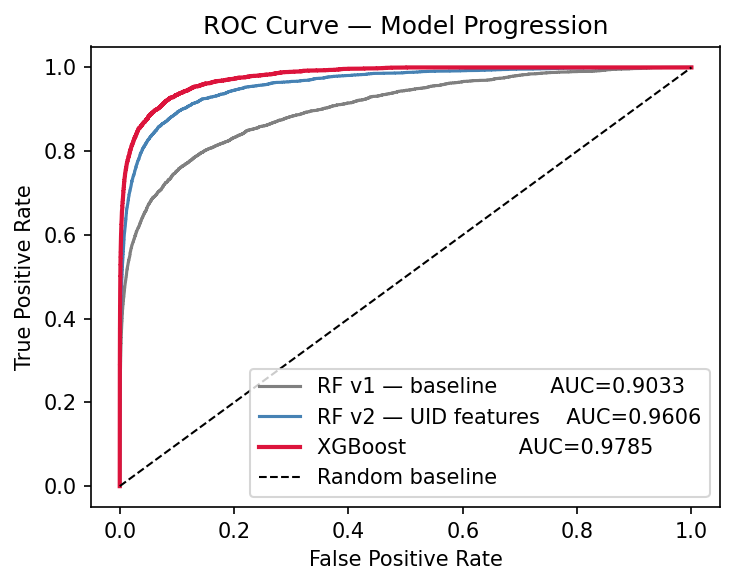

In [53]:
from sklearn.metrics import roc_curve

fpr_rf1, tpr_rf1, _ = roc_curve(y_test,   y_prob_rf)
fpr_rf2, tpr_rf2, _ = roc_curve(y2_test,  y2_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y2_test,  y_prob_xgb)

plt.figure(figsize=(5, 4))
plt.plot(fpr_rf1, tpr_rf1, label=f'RF v1 — baseline        AUC={0.9033}', color='gray',      linewidth=1.5)
plt.plot(fpr_rf2, tpr_rf2, label=f'RF v2 — UID features    AUC={roc_auc_score(y2_test, y2_prob):.4f}',  color='steelblue', linewidth=1.5)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost                 AUC={roc_auc_score(y2_test, y_prob_xgb):.4f}', color='crimson',   linewidth=2)
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Progression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

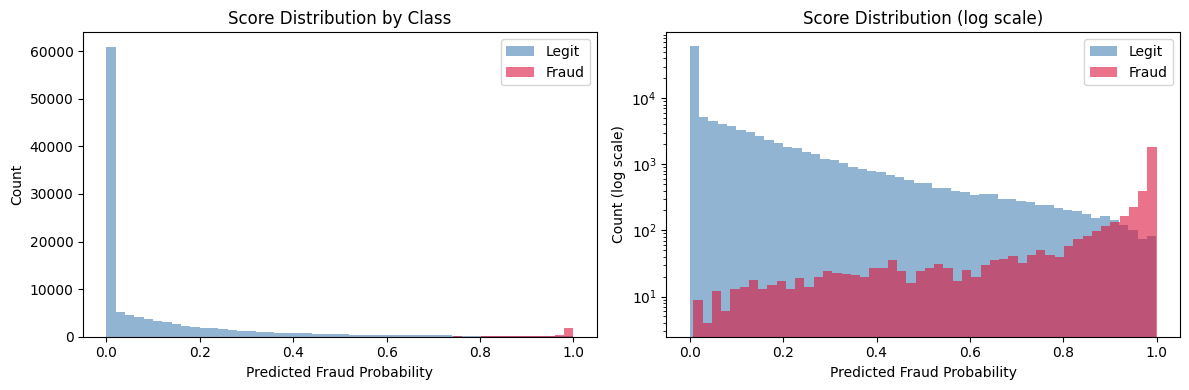

In [40]:
# Look at how fraud probability is distributed
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_prob_xgb[y2_test.values == 0], bins=50,
         alpha=0.6, color='steelblue', label='Legit')
plt.hist(y_prob_xgb[y2_test.values == 1], bins=50,
         alpha=0.6, color='crimson', label='Fraud')
plt.xlabel('Predicted Fraud Probability')
plt.ylabel('Count')
plt.title('Score Distribution by Class')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_prob_xgb[y2_test.values == 0], bins=50,
         alpha=0.6, color='steelblue', label='Legit')
plt.hist(y_prob_xgb[y2_test.values == 1], bins=50,
         alpha=0.6, color='crimson', label='Fraud')
plt.yscale('log')
plt.xlabel('Predicted Fraud Probability')
plt.ylabel('Count (log scale)')
plt.title('Score Distribution (log scale)')
plt.legend()

plt.tight_layout()
plt.show()

Best F1 threshold: 0.8765
Precision at best threshold: 0.8051
Recall at best threshold:    0.7017
F1 at best threshold:        0.7498


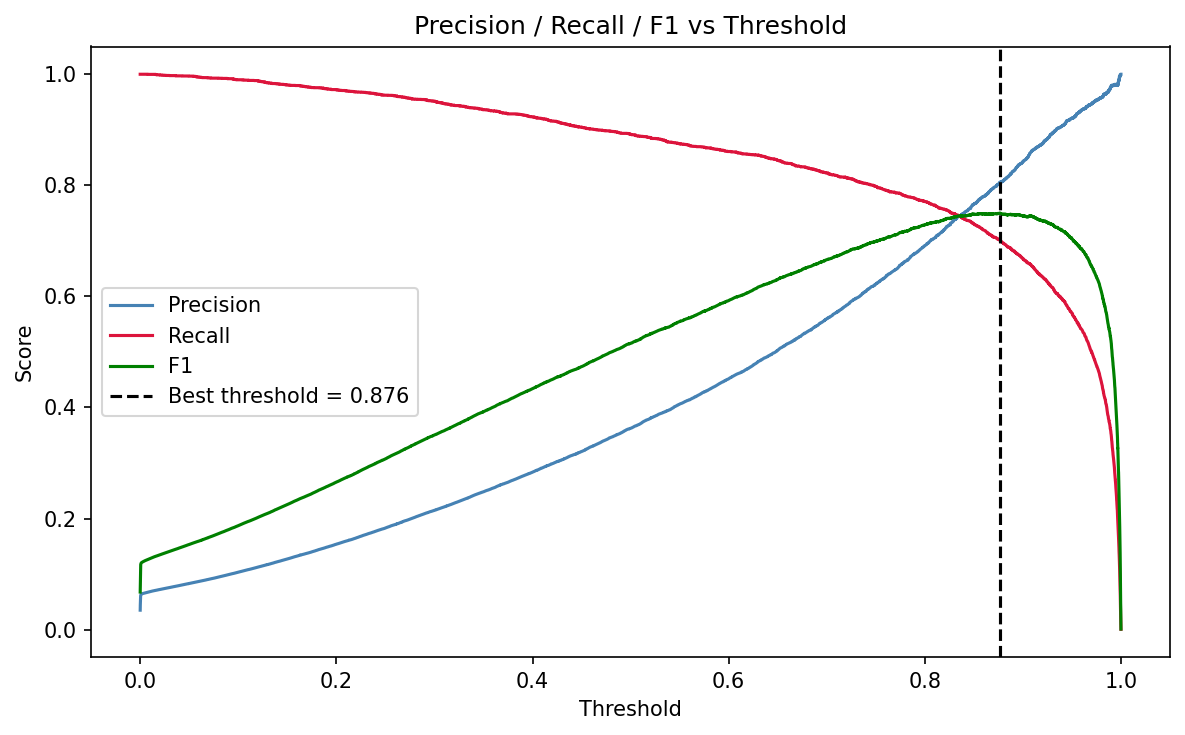

In [59]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y2_test, y_prob_xgb)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh_idx = f1_scores.argmax()
best_threshold  = thresholds[best_thresh_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Precision at best threshold: {precision[best_thresh_idx]:.4f}")
print(f"Recall at best threshold:    {recall[best_thresh_idx]:.4f}")
print(f"F1 at best threshold:        {f1_scores[best_thresh_idx]:.4f}")

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1],    label='Recall',    color='crimson')
plt.plot(thresholds, f1_scores[:-1], label='F1',        color='green')
plt.axvline(best_threshold, color='black', linestyle='--',
            label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# Thresholds from your paper's methodology
THRESHOLD_LOW    = 0.35
THRESHOLD_HIGH   = 0.70

def assign_risk_tier(prob):
    if prob < THRESHOLD_LOW:
        return 'Low'
    elif prob < THRESHOLD_HIGH:
        return 'Medium'
    else:
        return 'High'

# Apply to test set
results_df = pd.DataFrame({
    'actual':     y2_test.values,
    'fraud_prob': y_prob_xgb,
    'risk_tier':  [assign_risk_tier(p) for p in y_prob_xgb]
})

# Distribution of risk tiers
print("Risk Tier Distribution:")
print(results_df['risk_tier'].value_counts())
print()

# Fraud rate within each tier — this is the key validation
print("Fraud rate per risk tier:")
print(results_df.groupby('risk_tier')['actual'].agg(['mean', 'sum', 'count'])
      .rename(columns={'mean':'fraud_rate', 'sum':'fraud_count', 'count':'total'})
      .round(4))

Risk Tier Distribution:
risk_tier
Low       102513
Medium      9521
High        6074
Name: count, dtype: int64

Fraud rate per risk tier:
           fraud_rate  fraud_count   total
risk_tier                                 
High           0.5596         3399    6074
Low            0.0026          264  102513
Medium         0.0494          470    9521


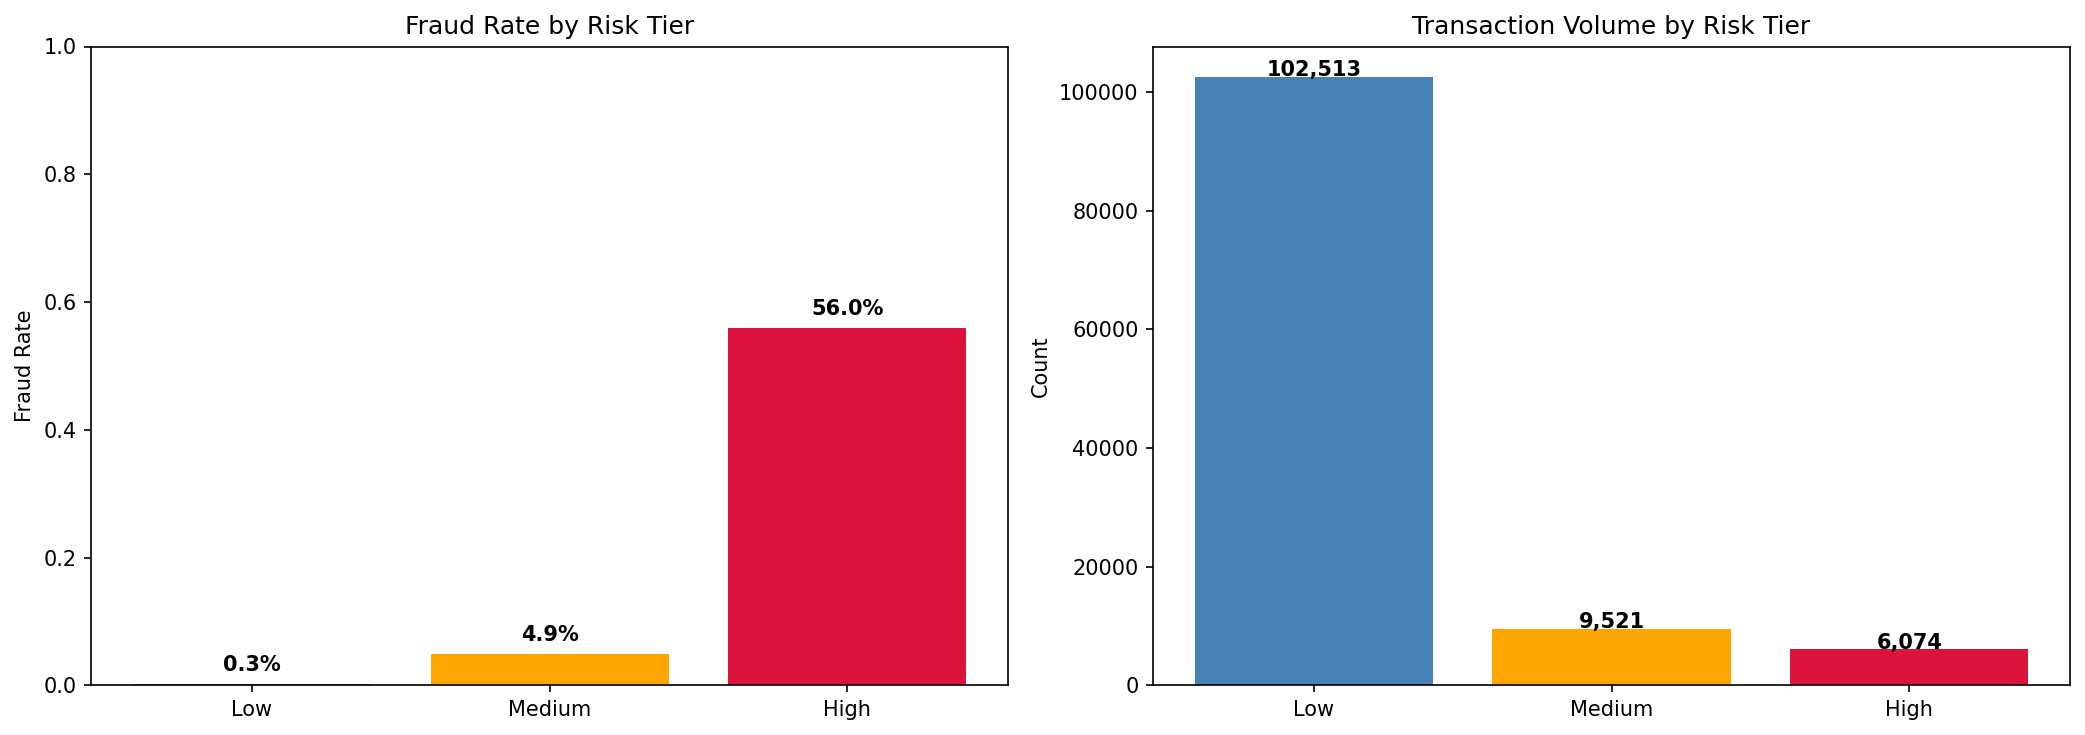

In [56]:
tier_order  = ['Low', 'Medium', 'High']
tier_colors = ['steelblue', 'orange', 'crimson']

fraud_rates = results_df.groupby('risk_tier')['actual'].mean()
fraud_rates = fraud_rates.reindex(tier_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate per tier
axes[0].bar(tier_order, fraud_rates.values, color=tier_colors)
axes[0].set_title('Fraud Rate by Risk Tier')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(fraud_rates.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Transaction volume per tier
tier_counts = results_df['risk_tier'].value_counts().reindex(tier_order)
axes[1].bar(tier_order, tier_counts.values, color=tier_colors)
axes[1].set_title('Transaction Volume by Risk Tier')
axes[1].set_ylabel('Count')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
prevention_actions = {
    'Low':    'Session proceeds normally',
    'Medium': 'OTP / CAPTCHA challenge issued',
    'High':   'Session blocked + security alert sent'
}

print("=" * 60)
print("PREVENTION MECHANISM SUMMARY")
print("=" * 60)

total = len(results_df)

for tier, color in zip(tier_order, ['✅', '⚠️', '🚨']):
    tier_df     = results_df[results_df['risk_tier'] == tier]
    count       = len(tier_df)
    fraud_count = tier_df['actual'].sum()
    fraud_rate  = tier_df['actual'].mean()
    action      = prevention_actions[tier]

    print(f"\n{color}  {tier} Risk")
    print(f"   Transactions : {count:,} ({count/total*100:.1f}% of total)")
    print(f"   Fraud caught : {fraud_count:,} ({fraud_rate*100:.1f}% fraud rate)")
    print(f"   Action       : {action}")

# How much fraud does the High tier catch?
high_df    = results_df[results_df['risk_tier'] == 'High']
total_fraud = results_df['actual'].sum()
caught      = high_df['actual'].sum()
print(f"\n{'='*60}")
print(f"High-risk tier catches {caught}/{total_fraud} fraud cases ({caught/total_fraud*100:.1f}% of all fraud)")
print(f"At cost of blocking    {(high_df['actual']==0).sum():,} legitimate transactions")

PREVENTION MECHANISM SUMMARY

✅  Low Risk
   Transactions : 102,513 (86.8% of total)
   Fraud caught : 264 (0.3% fraud rate)
   Action       : Session proceeds normally

⚠️  Medium Risk
   Transactions : 9,521 (8.1% of total)
   Fraud caught : 470 (4.9% fraud rate)
   Action       : OTP / CAPTCHA challenge issued

🚨  High Risk
   Transactions : 6,074 (5.1% of total)
   Fraud caught : 3,399 (56.0% fraud rate)
   Action       : Session blocked + security alert sent

High-risk tier catches 3399/4133 fraud cases (82.2% of all fraud)
At cost of blocking    2,675 legitimate transactions


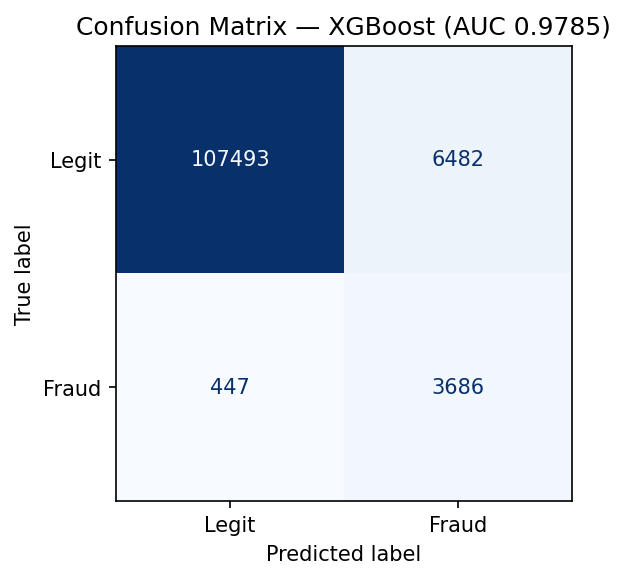

True Negatives  (Legit correctly allowed):  107,493
False Positives (Legit wrongly blocked):     6,482
False Negatives (Fraud missed):              447
True Positives  (Fraud correctly caught):    3,686

Fraud catch rate (Recall): 89.2%
False alarm rate:          5.7%


In [55]:
cm = confusion_matrix(y2_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — XGBoost (AUC 0.9785)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Legit correctly allowed):  {tn:,}")
print(f"False Positives (Legit wrongly blocked):     {fp:,}")
print(f"False Negatives (Fraud missed):              {fn:,}")
print(f"True Positives  (Fraud correctly caught):    {tp:,}")
print(f"\nFraud catch rate (Recall): {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate:          {fp/(fp+tn)*100:.1f}%")

In [46]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'